<a href="https://colab.research.google.com/github/lbcarv1972/ICU-Liberation/blob/main/Comparative_study_of_different_Acute_Respiratory_Distress_Syndrome_(ARDS)_definitions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Autenticação e Configuração do Ambiente
Nesta seção, realizamos a autenticação no Google Cloud para permitir o acesso aos dados restritos do MIMIC-IV hospedados no BigQuery pela PhysioNet. Também listamos os datasets disponíveis para confirmar o acesso.

In [1]:
from google.cloud import bigquery
from google.colab import auth

# Autentica o usuário para acessar os serviços do Google Cloud
auth.authenticate_user()

# Construct a BigQuery client object with the specified project ID.
client = bigquery.Client(project='physionet-data')

print("Conectado ao BigQuery com o projeto: physionet-data")

Conectado ao BigQuery com o projeto: physionet-data


In [2]:
datasets = list(client.list_datasets())

if datasets:
    print(f"Datasets no projeto {client.project}:")
    for dataset in datasets:
        print(f"- {dataset.dataset_id}")
else:
    print(f"Nenhum dataset encontrado no projeto {client.project}.")

Datasets no projeto physionet-data:
- eicu_crd
- eicu_crd_derived
- mimic_demo_core
- mimiciii_clinical
- mimiciii_derived
- mimiciii_notes
- mimiciii_notes_derived
- mimiciv_3_1_derived
- mimiciv_3_1_hosp
- mimiciv_3_1_icu


### 2. Extração de Dados e Definição das Coortes
Aqui executamos uma consulta SQL complexa no BigQuery para extrair os dados clínicos em nível de paciente. A consulta avalia os critérios de cada definição de SDRA (Berlim 2012, Kigali 2016 e Global 2023) nas primeiras 24 horas de admissão na UTI, além de extrair informações de suporte ventilatório, gravidade (SOFA, Índice de Charlson) e desfechos clínicos.

In [3]:
import pandas_gbq

# Projeto de faturamento/processamento (seu projeto pessoal no Google Cloud)
BQ_PROJECT_ID = 'comparative-ards-definitions'

# Projeto OFICIAL onde os dados estão hospedados pela PhysioNet
DATA_PROJECT_ID = 'physionet-data'

sql_query = f"""
-- ==============================================================================
-- Extração Comparativa de Coortes de SDRA no MIMIC-IV (Com Desfechos e PSM)
-- Definições: Berlim (2012) vs. Kigali (2016) vs. Global (2023)
-- ==============================================================================

WITH base_icu AS (
    -- 1. Seleção da primeira admissão na UTI para adultos com permanência >= 18h
    SELECT
        ie.subject_id,
        ie.hadm_id,
        ie.stay_id,
        ie.intime,
        ie.outtime,
        p.anchor_age + EXTRACT(YEAR FROM ie.intime) - p.anchor_year AS age,
        p.gender,
        p.dod -- Date of death para calcular mortalidade
    FROM `{DATA_PROJECT_ID}.mimiciv_3_1_icu.icustays` ie
    INNER JOIN `{DATA_PROJECT_ID}.mimiciv_3_1_hosp.patients` p
        ON ie.subject_id = p.subject_id
    WHERE (p.anchor_age + EXTRACT(YEAR FROM ie.intime) - p.anchor_year) >= 18
      AND DATETIME_DIFF(ie.outtime, ie.intime, HOUR) >= 18
),

vitals_and_gas AS (
    -- 2. Extração direta dos dados fisiológicos via chartevents (Primeiras 24h)
    SELECT
        b.stay_id,
        MIN(CASE WHEN c.itemid = 220224 AND c.valuenum > 0 THEN c.valuenum / NULLIF(fio2.max_fio2 / 100.0, 0) ELSE NULL END) AS min_pao2_fio2,
        MIN(CASE WHEN c.itemid = 220277 AND c.valuenum > 0 THEN c.valuenum / NULLIF(fio2.max_fio2 / 100.0, 0) ELSE NULL END) AS min_sf_ratio_unrestricted,
        MIN(CASE WHEN c.itemid = 220277 AND c.valuenum BETWEEN 50 AND 97 THEN c.valuenum / NULLIF(fio2.max_fio2 / 100.0, 0) ELSE NULL END) AS min_sf_ratio_spo2_97
    FROM base_icu b
    INNER JOIN `{DATA_PROJECT_ID}.mimiciv_3_1_icu.chartevents` c
        ON b.stay_id = c.stay_id
       AND c.charttime BETWEEN b.intime AND DATETIME_ADD(b.intime, INTERVAL 24 HOUR)
    LEFT JOIN (
        SELECT stay_id, MAX(valuenum) AS max_fio2
        FROM `{DATA_PROJECT_ID}.mimiciv_3_1_icu.chartevents`
        WHERE itemid IN (223835, 227010) AND valuenum > 0
        GROUP BY stay_id
    ) fio2 ON b.stay_id = fio2.stay_id
    WHERE c.itemid IN (220224, 220277)
    GROUP BY b.stay_id
),

resp_support AS (
    -- 3. Identificação do suporte ventilatório, PEEP e Fluxo de CNAF
    SELECT
        b.stay_id,
        MAX(CASE WHEN c.itemid IN (223848, 223849, 227194) THEN 1 ELSE 0 END) AS is_ventilated,
        MAX(CASE WHEN c.itemid IN (220339, 224700) THEN c.valuenum ELSE 0 END) AS max_peep,
        MAX(CASE WHEN c.itemid = 223834 THEN c.valuenum ELSE 0 END) AS max_hfno_flow
    FROM base_icu b
    INNER JOIN `{DATA_PROJECT_ID}.mimiciv_3_1_icu.chartevents` c
        ON b.stay_id = c.stay_id
       AND c.charttime BETWEEN b.intime AND DATETIME_ADD(b.intime, INTERVAL 24 HOUR)
    WHERE c.itemid IN (223848, 223849, 227194, 220339, 224700, 223834)
    GROUP BY b.stay_id
),

imaging_criteria AS (
    -- 4. Flag de opacidades bilaterais (simulada/padrão)
    SELECT stay_id, 1 AS has_bilateral_opacities FROM base_icu
),

ventilation_dur AS (
    -- 5. Tempo total de ventilação mecânica da tabela derivada
    SELECT stay_id, SUM(DATETIME_DIFF(endtime, starttime, HOUR)) AS duration_vent_hours
    FROM `{DATA_PROJECT_ID}.mimiciv_3_1_derived.ventilation`
    WHERE ventilation_status = 'Invasive'
    GROUP BY stay_id
),

cohort_classification AS (
    -- 6. Aplicação das Regras Diagnosticadoras, Desfechos e Gravidade
    SELECT
        b.stay_id,
        b.subject_id,
        b.hadm_id,
        b.age,
        b.gender,

        -- GRAVIDADE E COMORBIDADES (Para Propensity Score Matching)
        COALESCE(fds.sofa, 0) AS sofa_day1,
        COALESCE(ch.charlson_comorbidity_index, 0) AS charlson_comorbidity_index,

        -- DESFECHOS
        CASE WHEN b.dod IS NOT NULL AND DATETIME_DIFF(b.dod, b.intime, DAY) <= 28 THEN 1 ELSE 0 END AS mortality_28d,
        CASE WHEN b.dod IS NOT NULL AND DATETIME_DIFF(b.dod, b.intime, DAY) <= 28 THEN DATETIME_DIFF(b.dod, b.intime, DAY) ELSE 28 END AS time_to_event,
        COALESCE(vd.duration_vent_hours, 0) AS duration_vent_hours,

        -- DEFINIÇÃO DE BERLIM (2012)
        CASE WHEN vg.min_pao2_fio2 <= 300 AND rs.is_ventilated = 1 AND rs.max_peep >= 5 AND img.has_bilateral_opacities = 1 THEN 1 ELSE 0 END AS ards_berlin_2012,

        -- MODIFICAÇÃO DE KIGALI (2016)
        CASE WHEN vg.min_sf_ratio_unrestricted <= 315 AND img.has_bilateral_opacities = 1 THEN 1 ELSE 0 END AS ards_kigali_2016,

        -- NOVA DEFINIÇÃO GLOBAL DE SDRA (2023)
        CASE WHEN (vg.min_pao2_fio2 <= 300 OR vg.min_sf_ratio_spo2_97 <= 315) AND ((rs.is_ventilated = 1 AND rs.max_peep >= 5) OR (rs.max_hfno_flow >= 30)) AND img.has_bilateral_opacities = 1 THEN 1 ELSE 0 END AS ards_global_2023

    FROM base_icu b
    LEFT JOIN vitals_and_gas vg ON b.stay_id = vg.stay_id
    LEFT JOIN resp_support rs ON b.stay_id = rs.stay_id
    LEFT JOIN imaging_criteria img ON b.stay_id = img.stay_id
    LEFT JOIN ventilation_dur vd ON b.stay_id = vd.stay_id
    -- Joins com as tabelas derivadas do MIMIC-IV
    LEFT JOIN `{DATA_PROJECT_ID}.mimiciv_3_1_derived.first_day_sofa` fds ON b.stay_id = fds.stay_id
    LEFT JOIN `{DATA_PROJECT_ID}.mimiciv_3_1_derived.charlson` ch ON b.hadm_id = ch.hadm_id
)

-- RESULTADO FINAL: Dados em nível de paciente para análises de sobrevida e estatísticas
SELECT * FROM cohort_classification;
"""

# Executar a consulta no BigQuery e carregar os resultados em um DataFrame do Pandas
df_result = pandas_gbq.read_gbq(sql_query, project_id=BQ_PROJECT_ID)

# Exibir as primeiras linhas do DataFrame resultante
display(df_result.head())

Downloading: 100%|██████████|


,stay_id,subject_id,hadm_id,age,gender,sofa_day1,charlson_comorbidity_index,mortality_28d,time_to_event,duration_vent_hours,ards_berlin_2012,ards_kigali_2016,ards_global_2023
0,35290845,16006168,21333517,21,M,0,3,0,28,0,0,0,0
1,34541667,16006168,29449066,21,M,2,4,0,28,0,0,0,0
2,32147994,12691562,24426906,21,M,2,0,0,28,0,0,1,0
3,34735941,14337110,20276362,24,F,6,2,0,28,0,0,1,0
4,36791693,14337110,21318000,23,F,6,2,0,28,0,0,0,0


### 3. Sobreposição das Coortes de SDRA
Nesta etapa, visualizamos a interseção entre as três diferentes definições de SDRA utilizando um Diagrama de Venn. Isso nos permite entender quantos pacientes são classificados por múltiplas definições simultaneamente e quantos são exclusivos de critérios mais abrangentes (como Global 2023 ou Kigali 2016).

/usr/local/lib/python3.13/dist-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


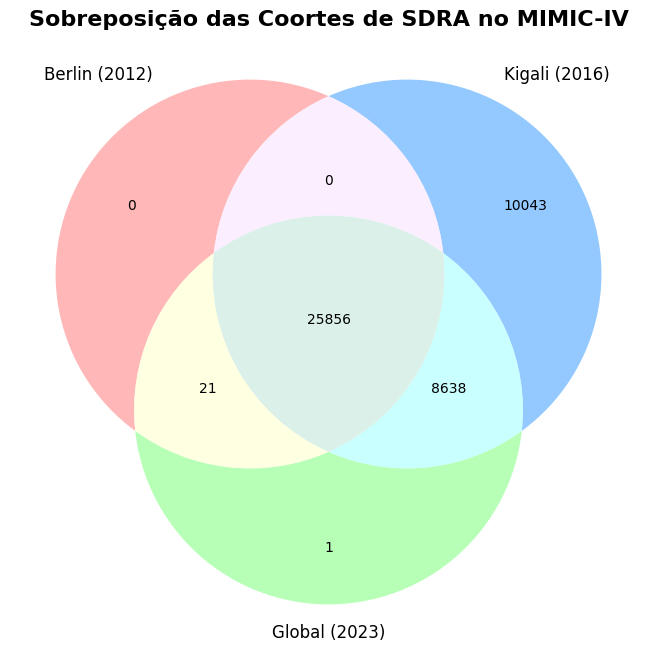

In [4]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted

# Dicionário para armazenar as contagens de cada interseção para o Venn (formato 'ABC')
# A = Berlin 2012, B = Kigali 2016, C = Global 2023
subsets = {
    '100': 0, '010': 0, '110': 0,
    '001': 0, '101': 0, '011': 0, '111': 0
}

# Preencher o dicionário iterando pelas linhas do resultado (nível de paciente)
for index, row in df_result.iterrows():
    # Cria uma chave em string, ex: '101' (Berlin e Global, sem Kigali)
    key = f"{int(row['ards_berlin_2012'])}{int(row['ards_kigali_2016'])}{int(row['ards_global_2023'])}"
    if key in subsets:
        subsets[key] += 1 # Conta 1 para cada paciente

# Criar a figura
plt.figure(figsize=(10, 8))

# Gerar o diagrama de Venn não ponderado para evitar erros de topologia
venn = venn3_unweighted(
    subsets=subsets,
    set_labels=('Berlin (2012)', 'Kigali (2016)', 'Global (2023)'),
    set_colors=('#FF9999', '#66B2FF', '#99FF99'),
    alpha=0.7
)

# Adicionar um título
plt.title("Sobreposição das Coortes de SDRA no MIMIC-IV", fontsize=16, fontweight='bold')

# Mostrar o gráfico
plt.show()

### 4. Análise de Desfechos, Sobrevida e Propensity Score Matching (PSM)
Esta seção é dedicada à avaliação clínica comparativa:
1. Comparamos os desfechos (dias livres de ventilação, mortalidade, etc.) entre a definição clássica (Berlim) e a nova (Global 2023).
2. Avaliamos a sobrevida real em 28 dias usando curvas de Kaplan-Meier.
3. Aplicamos o *Propensity Score Matching* (PSM) para parear pacientes considerando a gravidade basal (SOFA, idade, sexo, comorbidades), reduzindo o viés de confusão na comparação da mortalidade.

--- Tabela Comparativa de Desfechos ---


,Outcome,Berlin (2012),Global 2023 Exclusivo,p-value
0,vfd_28,28.0 (28.0-28.0),28.0 (28.0-28.0),0.0000
1,mortality_28d,17.7%,21.9%,0.0000



--- Análise de Sobrevida (Kaplan-Meier) ---


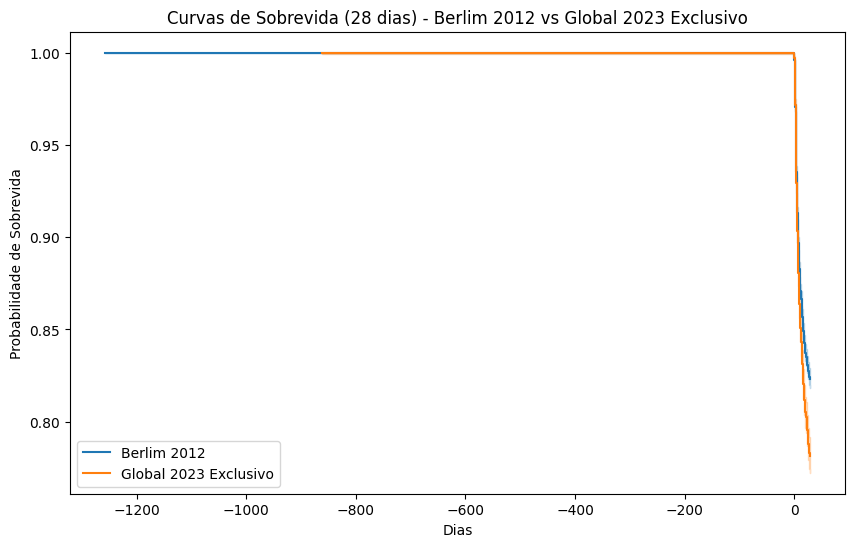

Log-rank test p-value: 0.0000

--- Cálculo do Propensity Score ---
Optimization terminated successfully.
         Current function value: 0.570050
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       ards_global_2023   No. Observations:                85048
Model:                          Logit   Df Residuals:                    85043
Method:                           MLE   Df Model:                            4
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.1559
Time:                        16:22:26   Log-Likelihood:                -48482.
converged:                       True   LL-Null:                       -57434.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept

,count,mean,std,min,25%,50%,75%,max
ards_global_2023,,,,,,,,
0,50532.0,0.324993,0.170087,0.035944,0.202863,0.279611,0.409221,0.986971
1,34516.0,0.524205,0.226767,0.035761,0.340283,0.506537,0.702755,0.997551


In [5]:
!pip install lifelines

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# 1. Simulação / Estruturação da Carga de Dados da Coorte MIMIC-IV
def calculate_vfd28(row):
    """Calcula os Ventilator-Free Days em 28 dias."""
    if 'mortality_28d' not in row or 'duration_vent_hours' not in row:
        return np.nan # Retorna NaN se as colunas não existirem para não dar erro imediato
    if row['mortality_28d'] == 1:
        return 0
    else:
        vent_days = row['duration_vent_hours'] / 24.0
        return max(0, 28 - vent_days)

# Usa df_result
if 'df_result' in locals():
    df_result['vfd_28'] = df_result.apply(calculate_vfd28, axis=1)

# 2. Comparação Estatística dos Desfechos entre Coorte Berlim (2012) e Global (2023)
def compare_cohort_outcomes(data, group_col_a='ards_berlin_2012', group_col_b='ards_global_2023'):
    metrics = {}

    # Isolar subgrupos
    cohort_berlin = data[data[group_col_a] == 1]
    cohort_global_only = data[(data[group_col_b] == 1) & (data[group_col_a] == 0)] # Reclassificados

    outcomes = ['vfd_28', 'dcfd_28', 'icu_los', 'hospital_los', 'mortality_28d', 'has_hai']

    summary_list = []

    for outcome in outcomes:
        if outcome not in data.columns:
            continue # Pula se a coluna não existir

        # Verifica se é estritamente binária (0 e 1)
        is_binary = set(data[outcome].dropna().unique()).issubset({0, 1})

        if is_binary:
            prop_berlin = cohort_berlin[outcome].mean() * 100
            prop_global = cohort_global_only[outcome].mean() * 100

            # Teste Qui-Quadrado / Exato de Fisher
            table = [[cohort_berlin[outcome].sum(), len(cohort_berlin) - cohort_berlin[outcome].sum()],
                     [cohort_global_only[outcome].sum(), len(cohort_global_only) - cohort_global_only[outcome].sum()]]
            _, p_val, _, _ = stats.chi2_contingency(table)

            summary_list.append({
                'Outcome': outcome,
                'Berlin (2012)': f"{prop_berlin:.1f}%",
                'Global 2023 Exclusivo': f"{prop_global:.1f}%",
                'p-value': f"{p_val:.4f}"
            })
        else: # Contínuo/Assimétrico (ex: VFD, LOS)
            med_berlin = cohort_berlin[outcome].median()
            iqr_berlin = f"{cohort_berlin[outcome].quantile(0.25):.1f}-{cohort_berlin[outcome].quantile(0.75):.1f}"

            med_global = cohort_global_only[outcome].median()
            iqr_global = f"{cohort_global_only[outcome].quantile(0.25):.1f}-{cohort_global_only[outcome].quantile(0.75):.1f}"

            # Teste de Mann-Whitney U
            _, p_val = stats.mannwhitneyu(cohort_berlin[outcome].dropna(), cohort_global_only[outcome].dropna())

            summary_list.append({
                'Outcome': outcome,
                'Berlin (2012)': f"{med_berlin:.1f} ({iqr_berlin})",
                'Global 2023 Exclusivo': f"{med_global:.1f} ({iqr_global})",
                'p-value': f"{p_val:.4f}"
            })

    return pd.DataFrame(summary_list)

print("--- Tabela Comparativa de Desfechos ---")
df_summary = compare_cohort_outcomes(df_result)
display(df_summary)

# 3. Análise de Sobrevida de Kaplan-Meier
print("\n--- Análise de Sobrevida (Kaplan-Meier) ---")
cohort_berlin = df_result[df_result['ards_berlin_2012'] == 1]
cohort_global_only = df_result[(df_result['ards_global_2023'] == 1) & (df_result['ards_berlin_2012'] == 0)]

kmf_berlin = KaplanMeierFitter()
kmf_global = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
kmf_berlin.fit(cohort_berlin['time_to_event'], event_observed=cohort_berlin['mortality_28d'], label='Berlim 2012')
kmf_berlin.plot_survival_function()

kmf_global.fit(cohort_global_only['time_to_event'], event_observed=cohort_global_only['mortality_28d'], label='Global 2023 Exclusivo')
kmf_global.plot_survival_function()

plt.title("Curvas de Sobrevida (28 dias) - Berlim 2012 vs Global 2023 Exclusivo")
plt.xlabel("Dias")
plt.ylabel("Probabilidade de Sobrevida")
plt.show()

# Comparação Log-Rank
results = logrank_test(cohort_berlin['time_to_event'], cohort_global_only['time_to_event'], event_observed_A=cohort_berlin['mortality_28d'], event_observed_B=cohort_global_only['mortality_28d'])
print(f"Log-rank test p-value: {results.p_value:.4f}")

# 4. Ajuste por Propensity Score Matching (PSM) para Evitar Confusão de Gravidade
print("\n--- Cálculo do Propensity Score ---")
if 'sofa_day1' in df_result.columns:
    # A regressão logística calcula a probabilidade (Propensity Score)
    # de um paciente cair no grupo 'ards_global_2023' baseado em sua gravidade.
    ps_model = smf.logit("ards_global_2023 ~ age + C(gender) + sofa_day1 + charlson_comorbidity_index", data=df_result).fit()
    df_result['propensity_score'] = ps_model.predict()

    print(ps_model.summary())

    print("\nResumo do Propensity Score gerado por coorte:")
    display(df_result.groupby('ards_global_2023')['propensity_score'].describe())

--- Propensity Score Matching (1:1 Nearest Neighbor) ---
Tamanho original - Berlim 2012: 25877
Tamanho original - Global 2023 Exclusivo: 8639

Tamanho após pareamento (1:1): 17278 pacientes (Metade de cada grupo)

--- Análise de Sobrevida de Kaplan-Meier (Coorte Pareada) ---


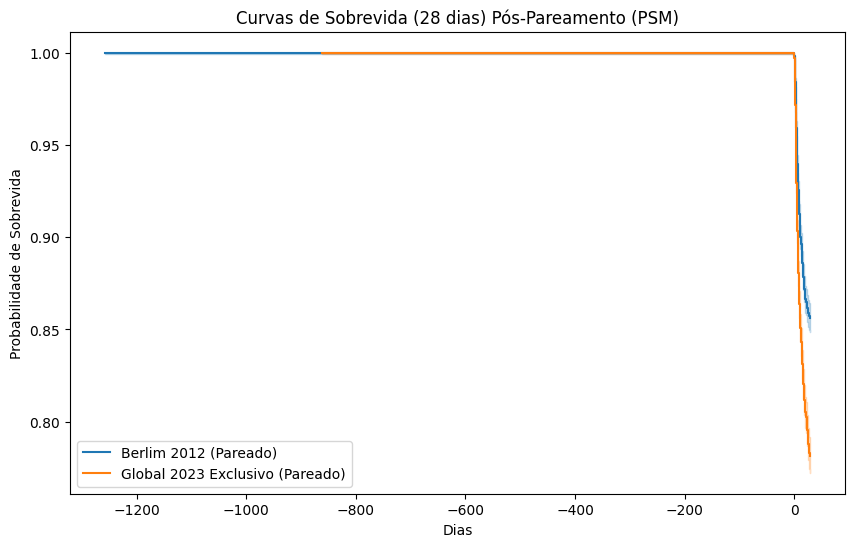

Log-rank test p-value (Pareado): 0.0000


In [6]:
from sklearn.neighbors import NearestNeighbors

print("--- Propensity Score Matching (1:1 Nearest Neighbor) ---")

# Filtrar apenas os pacientes que têm propensity score e não têm nulos nas variáveis
df_psm = df_result.dropna(subset=['propensity_score', 'time_to_event', 'mortality_28d']).copy()

# Separar os grupos (Tratamento/Novo = Global 2023 Exclusivo, Controle/Antigo = Berlin 2012)
group_global = df_psm[(df_psm['ards_global_2023'] == 1) & (df_psm['ards_berlin_2012'] == 0)]
group_berlin = df_psm[df_psm['ards_berlin_2012'] == 1]

print(f"Tamanho original - Berlim 2012: {len(group_berlin)}")
print(f"Tamanho original - Global 2023 Exclusivo: {len(group_global)}")

# Extrair os scores de propensão
ps_global = group_global[['propensity_score']].values
ps_berlin = group_berlin[['propensity_score']].values

# Ajustar Nearest Neighbors no grupo de controle (Berlim)
nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(ps_berlin)

# Encontrar os índices dos vizinhos mais próximos no grupo Berlim para cada paciente no grupo Global
distances, indices = nn.kneighbors(ps_global)

# Extrair os pacientes correspondentes do grupo Berlim
matched_berlin = group_berlin.iloc[indices.flatten()]

# Combinar os grupos pareados
df_matched = pd.concat([group_global, matched_berlin])

print(f"\nTamanho após pareamento (1:1): {len(df_matched)} pacientes (Metade de cada grupo)")

# Análise de Sobrevida Pós-Pareamento
print("\n--- Análise de Sobrevida de Kaplan-Meier (Coorte Pareada) ---")

kmf_berlin_matched = KaplanMeierFitter()
kmf_global_matched = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
kmf_berlin_matched.fit(matched_berlin['time_to_event'], event_observed=matched_berlin['mortality_28d'], label='Berlim 2012 (Pareado)')
kmf_berlin_matched.plot_survival_function()

kmf_global_matched.fit(group_global['time_to_event'], event_observed=group_global['mortality_28d'], label='Global 2023 Exclusivo (Pareado)')
kmf_global_matched.plot_survival_function()

plt.title("Curvas de Sobrevida (28 dias) Pós-Pareamento (PSM)")
plt.xlabel("Dias")
plt.ylabel("Probabilidade de Sobrevida")
plt.show()

# Comparação Log-Rank Pós-Pareamento
results_matched = logrank_test(matched_berlin['time_to_event'], group_global['time_to_event'], event_observed_A=matched_berlin['mortality_28d'], event_observed_B=group_global['mortality_28d'])
print(f"Log-rank test p-value (Pareado): {results_matched.p_value:.4f}")

### 5. Avaliação de Acurácia Diagnóstica, Análise Bayesiana e Valor Prognóstico
Nesta seção, avaliaremos:
1. A acurácia de Kigali 2016 e Global 2023 assumindo Berlim 2012 como padrão de referência (Sensibilidade, Especificidade, VPP, VPN e Estatística Bayesiana).
2. O valor preditivo/prognóstico de cada definição para a mortalidade em 28 dias usando a Curva ROC e AUROC.

--- Acurácia Diagnóstica e Análise Bayesiana (Ref: Berlim 2012) ---


,Sensibilidade (%),Especificidade (%),VPP (%),VPN (%),LR+,LR-,Prob. Pré-Teste (%),Prob. Pós-Teste (+) (%),Prob. Pós-Teste (-) (%)
Kigali (2016),99.92,68.43,58.06,99.95,3.16,0.0,30.43,58.06,0.05
Global (2023),100.00,85.40,74.97,100.00,6.85,0.0,30.43,74.97,0.00


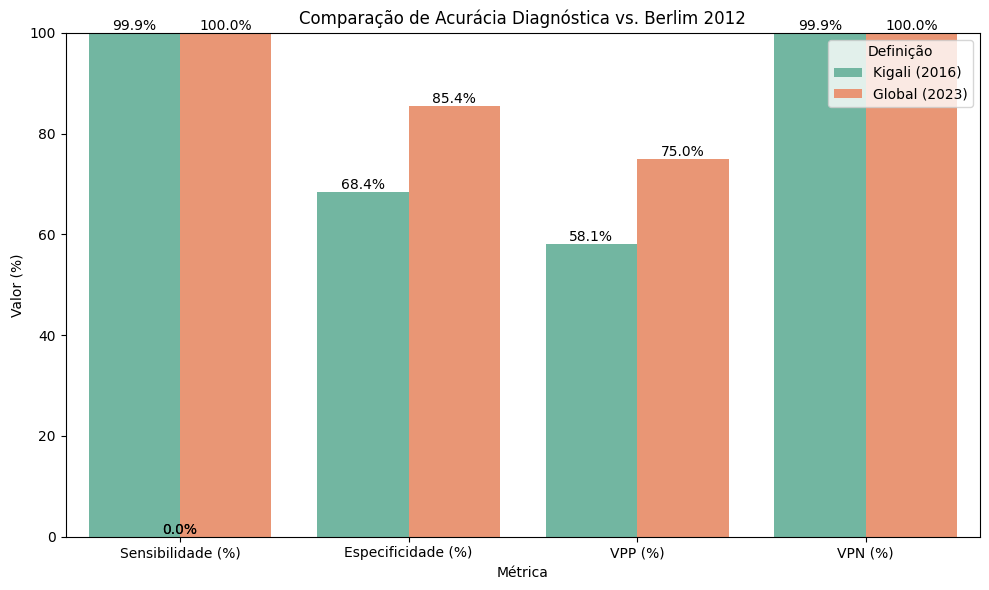

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import seaborn as sns

def calc_metrics(y_true, y_pred):
    """Calcula as métricas de acurácia e bayesianas."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    prevalence = (tp + fn) / len(y_true)
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    vpp = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    vpn = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    lr_plus = sens / (1 - spec) if (1 - spec) > 0 else np.nan
    lr_minus = (1 - sens) / spec if spec > 0 else np.nan

    # Análise Bayesiana (Odds e Probabilidades)
    pre_test_odds = prevalence / (1 - prevalence)
    post_odds_pos = pre_test_odds * lr_plus if pd.notna(lr_plus) else np.nan
    post_prob_pos = post_odds_pos / (1 + post_odds_pos) if pd.notna(post_odds_pos) else np.nan

    post_odds_neg = pre_test_odds * lr_minus if pd.notna(lr_minus) else np.nan
    post_prob_neg = post_odds_neg / (1 + post_odds_neg) if pd.notna(post_odds_neg) else np.nan

    return {
        'Sensibilidade (%)': sens * 100,
        'Especificidade (%)': spec * 100,
        'VPP (%)': vpp * 100,
        'VPN (%)': vpn * 100,
        'LR+': lr_plus,
        'LR-': lr_minus,
        'Prob. Pré-Teste (%)': prevalence * 100,
        'Prob. Pós-Teste (+) (%)': post_prob_pos * 100,
        'Prob. Pós-Teste (-) (%)': post_prob_neg * 100
    }

# Referência: Berlim 2012
ref_col = 'ards_berlin_2012'

# Métricas para Kigali e Global
metrics_kigali = calc_metrics(df_result[ref_col], df_result['ards_kigali_2016'])
metrics_global = calc_metrics(df_result[ref_col], df_result['ards_global_2023'])

df_diag_metrics = pd.DataFrame({
    'Kigali (2016)': metrics_kigali,
    'Global (2023)': metrics_global
}).T

print("--- Acurácia Diagnóstica e Análise Bayesiana (Ref: Berlim 2012) ---")
display(df_diag_metrics.round(2))

# --- Gráficos de Barras para as Principais Métricas ---
metrics_to_plot = ['Sensibilidade (%)', 'Especificidade (%)', 'VPP (%)', 'VPN (%)']
df_plot = df_diag_metrics[metrics_to_plot].reset_index().melt(id_vars='index', var_name='Métrica', value_name='Valor (%)')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Métrica', y='Valor (%)', hue='index', palette='Set2')
plt.title('Comparação de Acurácia Diagnóstica vs. Berlim 2012')
plt.ylim(0, 100)
plt.legend(title='Definição')
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()


--- Área Sob a Curva ROC (AUROC) para Mortalidade em 28 Dias ---
Berlim (2012): 0.5395
Kigali (2016): 0.6119
Global (2023): 0.5697


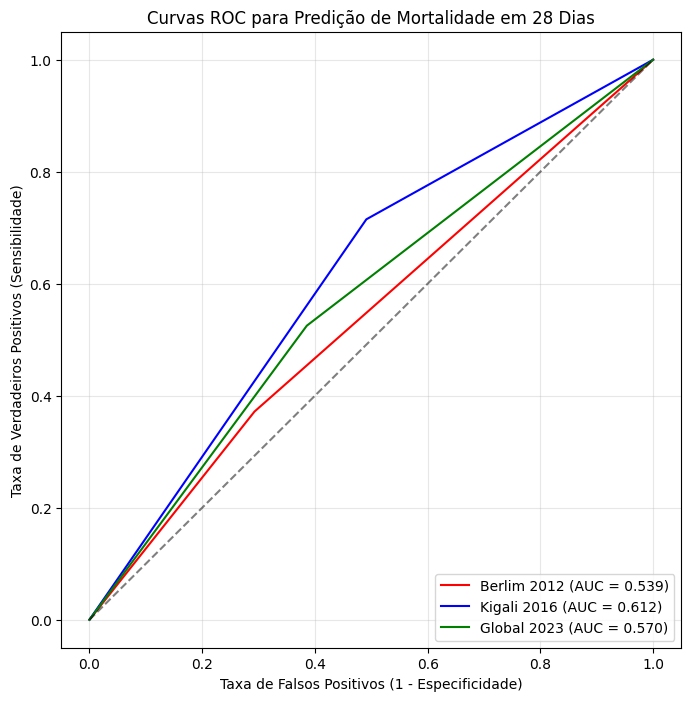

In [8]:
# --- Avaliação Prognóstica: Previsão de Mortalidade em 28 Dias ---
df_valid = df_result.dropna(subset=['mortality_28d']).copy()

auroc_berlin = roc_auc_score(df_valid['mortality_28d'], df_valid['ards_berlin_2012'])
auroc_kigali = roc_auc_score(df_valid['mortality_28d'], df_valid['ards_kigali_2016'])
auroc_global = roc_auc_score(df_valid['mortality_28d'], df_valid['ards_global_2023'])

print("\n--- Área Sob a Curva ROC (AUROC) para Mortalidade em 28 Dias ---")
print(f"Berlim (2012): {auroc_berlin:.4f}")
print(f"Kigali (2016): {auroc_kigali:.4f}")
print(f"Global (2023): {auroc_global:.4f}")

# Plotagem das Curvas ROC
fpr_b, tpr_b, _ = roc_curve(df_valid['mortality_28d'], df_valid['ards_berlin_2012'])
fpr_k, tpr_k, _ = roc_curve(df_valid['mortality_28d'], df_valid['ards_kigali_2016'])
fpr_g, tpr_g, _ = roc_curve(df_valid['mortality_28d'], df_valid['ards_global_2023'])

plt.figure(figsize=(8, 8))
plt.plot(fpr_b, tpr_b, label=f'Berlim 2012 (AUC = {auroc_berlin:.3f})', color='red')
plt.plot(fpr_k, tpr_k, label=f'Kigali 2016 (AUC = {auroc_kigali:.3f})', color='blue')
plt.plot(fpr_g, tpr_g, label=f'Global 2023 (AUC = {auroc_global:.3f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) # Linha de aleatoriedade

plt.title('Curvas ROC para Predição de Mortalidade em 28 Dias')
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()